
<h2 style="text-align: left; font-family: Georgia, serif; color: #ffffff; font-size: 22px; background-color: #2C3E50; padding: 10px 15px; border-radius: 6px;">
Phase 9 — Feature Engineering
</h2>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("himalayan_expeditions_cleaned.csv")
df['total_people'] = df['members'] + df['hired_staff']

print("=" * 60)
print("Total number of people (members + hired_staff) in each row")
print("=" * 60)
print(df['total_people'].head(10))

Total number of people (members + hired_staff) in each row
0    19
1    10
2    14
3     2
4     3
5     8
6     9
7    19
8    12
9     5
Name: total_people, dtype: int64


In [3]:
df['staff_ratio'] = df['hired_staff'] / (df['members'] + df['hired_staff'])

print("=" * 60)
print("Staff Ratio for each row (hired_staff / total_people)")
print("=" * 60)
print(df['staff_ratio'].head(10))

Staff Ratio for each row (hired_staff / total_people)
0    0.473684
1    0.000000
2    0.571429
3    0.000000
4    0.000000
5    0.250000
6    0.222222
7    0.000000
8    0.250000
9    0.000000
Name: staff_ratio, dtype: float64


In [4]:
# Drop unnecessary columns
df = df.drop(columns=['members', 'hired_staff', 'member_deaths', 'hired_staff_deaths', 'highpoint_metres', 'year'])

print("=" * 60)
print("Remaining columns:")
print("=" * 60)
print(df.columns)

Remaining columns:
Index(['peak_name', 'season', 'termination_reason', 'oxygen_used',
       'total_people', 'staff_ratio'],
      dtype='object')


In [5]:
df['success'] = df['termination_reason'].apply(lambda x: 1 if "Success" in x else 0)

df = df.drop(columns=['termination_reason'])

print("=" * 60)
print("Example values for 'success':")
print("=" * 60)
print(df['success'].head(10))


Example values for 'success':
0    1
1    1
2    1
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: success, dtype: int64


In [6]:
df['oxygen_used'] = df['oxygen_used'].astype(int)

print("=" * 60)
print("Example values for 'oxygen_used':")
print("=" * 60)
print(df['oxygen_used'].head(10))

Example values for 'oxygen_used':
0    1
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: oxygen_used, dtype: int64


In [7]:
df = pd.get_dummies(df, columns=['season'], drop_first=True)

print("=" * 60)
print("Remaining columns after dummies:")
print("=" * 60)
print(df.columns)

Remaining columns after dummies:
Index(['peak_name', 'oxygen_used', 'total_people', 'staff_ratio', 'success',
       'season_Spring', 'season_Summer', 'season_Unknown', 'season_Winter'],
      dtype='object')


In [8]:
df = df.rename(columns={'season_Unknown': 'season_Autumn'})

print("=" * 60)
print("Renamed column 'season_Unknown' to 'season_Autumn'")
print("=" * 60)
print(df.columns)

Renamed column 'season_Unknown' to 'season_Autumn'
Index(['peak_name', 'oxygen_used', 'total_people', 'staff_ratio', 'success',
       'season_Spring', 'season_Summer', 'season_Autumn', 'season_Winter'],
      dtype='object')


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['peak_name_encoded'] = le.fit_transform(df['peak_name'])
df = df.drop(columns=['peak_name'])

print("=" * 60)
print("Encoded 'peak_name' column using LabelEncoder")
print(df['peak_name_encoded'].head(10))
print("=" * 60)

Encoded 'peak_name' column using LabelEncoder
0    10
1    10
2    10
3    10
4    10
5    10
6    10
7    10
8    10
9    10
Name: peak_name_encoded, dtype: int64


In [10]:
season_cols = ['season_Spring', 'season_Summer', 'season_Autumn', 'season_Winter']
df[season_cols] = df[season_cols].astype(int)

print("=" * 60)
print("Converted season dummy columns to integer type:")
print("=" * 60)
print(df[season_cols].head())

Converted season dummy columns to integer type:
   season_Spring  season_Summer  season_Autumn  season_Winter
0              1              0              0              0
1              0              0              0              0
2              1              0              0              0
3              0              0              0              0
4              0              0              0              0


In [11]:
print("=" * 60)
print("First 10 values of dataframe")
print("=" * 60)
print(df.head(10).to_string(index=False))  

First 10 values of dataframe
 oxygen_used  total_people  staff_ratio  success  season_Spring  season_Summer  season_Autumn  season_Winter  peak_name_encoded
           1            19     0.473684        1              1              0              0              0                 10
           0            10     0.000000        1              0              0              0              0                 10
           0            14     0.571429        1              1              0              0              0                 10
           0             2     0.000000        0              0              0              0              0                 10
           0             3     0.000000        0              0              0              0              0                 10
           0             8     0.250000        0              1              0              0              0                 10
           0             9     0.222222        0              1            

In [12]:
df.isnull().sum()

print("=" * 60)
print("Total null values in dataframe")
print("=" * 60)

Total null values in dataframe


In [13]:
df = df.dropna()

print("=" * 60)
print("Dropped rows containing missing values (NaN).")
print("New shape of DataFrame:", df.shape)
print("=" * 60)

Dropped rows containing missing values (NaN).
New shape of DataFrame: (10328, 9)



<h2 style="text-align: left; font-family: Georgia, serif; color: #ffffff; font-size: 22px; background-color: #2C3E50; padding: 10px 15px; border-radius: 6px;">
Phase 10 — Prediction using scikit-learn
</h2>

In [14]:
X = df.drop(columns=['success'])
y = df['success']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=" * 60)
print("Data Split Complete")
print("=" * 60)
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Data Split Complete
Training set size: 8262
Testing set size: 2066


In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [17]:
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("=" * 60)
print("Prediction Results")
print("=" * 60)
print("Accuracy:", accuracy_score(y_test, y_pred))

Prediction Results
Accuracy: 0.6505324298160697


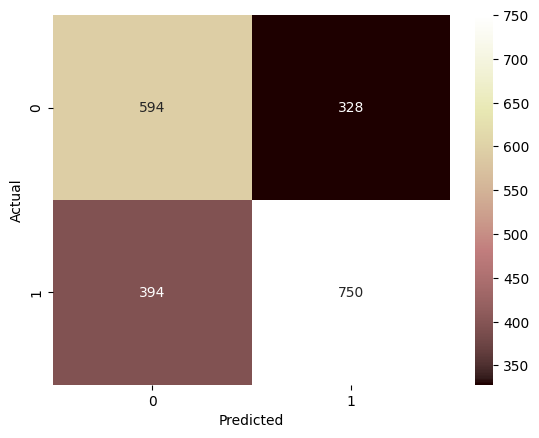

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='pink')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [20]:
print("="*60)
print("Himalayan Expedition Success Predictor")
print("="*60)

while True:
    try:
        oxygen_used = int(input("Did you use oxygen? (0 = No, 1 = Yes): "))
        if oxygen_used in [0, 1]:
            break
        else:
            print("Please enter 0 or 1.")
    except:
        print("Invalid input! Enter 0 or 1.")

while True:
    try:
        members = int(input("Number of members in your team: "))
        if members >= 0:
            break
        else:
            print("Enter a non-negative number.")
    except:
        print("Invalid input! Enter a number.")

while True:
    try:
        hired_staff = int(input("Number of hired staff: "))
        if hired_staff >= 0:
            break
        else:
            print("Enter a non-negative number.")
    except:
        print("Invalid input! Enter a number.")

total_people = members + hired_staff
staff_ratio = hired_staff / total_people if total_people > 0 else 0

seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
while True:
    season = input("Enter season (Spring, Summer, Autumn, Winter): ").capitalize()
    if season in seasons:
        break
    else:
        print("Invalid season! Please enter one of: Spring, Summer, Autumn, Winter.")

season_input = [1 if s == season else 0 for s in seasons]

peak_name = input("Enter peak name (e.g., Everest, Ama Dablam): ")
try:
    peak_encoded = le.transform([peak_name])[0]
except:
    print("Peak not recognized! Using default peak.")
    peak_encoded = 0

user_df = pd.DataFrame([[oxygen_used, total_people, staff_ratio] + season_input + [peak_encoded]],
                       columns=['oxygen_used','total_people','staff_ratio'] + 
                               ['season_Spring','season_Summer','season_Autumn','season_Winter'] + 
                               ['peak_name_encoded'])

pred = model.predict(user_df)[0]
prob = model.predict_proba(user_df)[0][1]

if pred == 1:
    print("="*60)
    print("Prediction: You are likely to SUCCEED! Probability:", prob)
else:
    print("="*60)
    print("Prediction: You are likely to FAIL. Probability:", prob)

Himalayan Expedition Success Predictor


Did you use oxygen? (0 = No, 1 = Yes):  1
Number of members in your team:  6
Number of hired staff:  5
Enter season (Spring, Summer, Autumn, Winter):  summer
Enter peak name (e.g., Everest, Ama Dablam):  makalu


Peak not recognized! Using default peak.
Prediction: You are likely to SUCCEED! Probability: 0.764872691026073


<p align="center">
<img src="https://media1.giphy.com/media/v1.Y2lkPTc5MGI3NjExNzI2NWhxMG91b2xzbDBoZWtreHd3Yjd1ajZkemh0dmw2Nmh3amk2MSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/m2HgaDX8IB4ujPcd9d/giphy.gif" width="200" style="border-radius: 10px;"/>
</p>

<p align="center" style="font-family: Georgia, serif; font-size: 14px; letter-spacing: 2px; text-transform: uppercase;">
✦ &nbsp; Author &nbsp;|&nbsp; <strong>Akisa Vujel</strong> &nbsp;|&nbsp; Data Analyst &nbsp; ✦
</p>